In [1]:
#import packages for numeric operations and working with structured data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import colors
import seaborn as sns
from scipy import stats

#import packages for unsupervised learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv('DM1_game_dataset.csv')

#UNDERSTANDING THE DATA

In [3]:
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [4]:
df.tail()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
21920,3233,Ballast,variation game quotpick sticksquot wooden cyli...,1998,1.0000,1.2096,2,4,8.0,11.0,...,21926,0,0,0,0,0,0,0,0,Low
21921,13359,Leapfrog,leapfrog fun family game simple young gamer pl...,2004,1.5000,1.7219,1,6,6.0,361.0,...,21926,0,0,0,0,0,0,0,0,Medium
21922,3295,Athos,monk climb athos mountain reach monastery move...,1993,1.6667,1.7946,2,4,11.0,431.0,...,21926,0,0,0,0,0,0,0,0,Low
21923,176524,Hoplomachus: Origins,hoplomachu origin take story begin small battl...,2015,3.0370,3.2921,1,2,13.8,322.0,...,21926,0,1,0,0,0,0,0,0,High
21924,4814,Rubout,rulesquotthe goal rubout player cash hand pl...,1989,1.7692,1.9113,2,8,12.0,1199.0,...,21926,0,0,0,0,0,1,0,0,Low


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21924 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            16395 non-null  float64
 9   LanguageEase         16034 non-null  float64
 10  BestPlayers          21925 non-null  int64  
 11  GoodPlayers          21925 non-null  object 
 12  NumOwned             21925 non-null  int64  
 13  NumWant              21925 non-null  int64  
 14  NumWish              21925 non-null  int64  
 15  NumWeightVotes       21925 non-null 

In [6]:
df.shape

(21925, 46)

In [7]:
df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase',
       'BestPlayers', 'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish',
       'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime',
       'MfgAgeRec', 'NumUserRatings', 'NumComments', 'NumAlternates',
       'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Family',
       'Kickstarted', 'ImagePath', 'Rank:strategygames', 'Rank:abstracts',
       'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames',
       'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic',
       'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract',
       'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')

In [8]:
df.describe()

,BGGId,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,BestPlayers,NumOwned,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
count,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,16395.000000,16034.000000,21925.000000,21925.000000,...,21925.000000,21925.000000,21925.000000,21925.00000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000,21925.000000
mean,117652.663216,1985.494914,1.982131,2.177479,2.007343,5.707868,10.004391,216.461819,0.311517,1467.848164,...,21295.352201,21062.680274,0.055827,0.10577,0.161003,0.105633,0.013820,0.050855,0.029190,0.040182
std,104628.721777,212.486214,0.848983,0.861781,0.693093,15.014643,3.269157,236.595136,1.067002,5294.120574,...,3637.139987,4219.776597,0.229592,0.30755,0.367542,0.307374,0.116745,0.219707,0.168344,0.196391
min,1.000000,-3500.000000,0.000000,0.000000,0.000000,0.000000,2.000000,1.000000,0.000000,0.000000,...,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,12346.000000,2001.000000,1.333300,1.513400,2.000000,4.000000,8.000000,24.027778,0.000000,150.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,105305.000000,2011.000000,1.968800,2.128000,2.000000,4.000000,10.000000,138.000000,0.000000,320.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,206169.000000,2017.000000,2.525200,2.737700,2.000000,6.000000,12.000000,351.000000,0.000000,899.000000,...,21926.000000,21926.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,349161.000000,2021.000000,5.000000,5.213200,10.000000,999.000000,21.000000,1757.000000,15.000000,166497.000000,...,21926.000000,21926.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.dtypes

,0
BGGId,int64
Name,object
Description,object
YearPublished,int64
GameWeight,float64
ComWeight,float64
MinPlayers,int64
MaxPlayers,int64
ComAgeRec,float64
LanguageEase,float64


#DATA TYPES

DATA TYPES:
Knowing the data types is necessary because it provides us the information that how the values in each column are stored and interpreted. Numeric columns (int64 and float64) typically represent quantitative variables, while object columns usually represent categorical or textual data.

In fact, to perform various analyses, it is necessary to convert certain columns to different data types as per the requirement of the model and operations. For instance, converting categorical variables to numerical representation.

In [10]:
# list of numerical features
numeric_features = df.select_dtypes(include=[np.number])
numeric_features.columns

Index(['BGGId', 'YearPublished', 'GameWeight', 'ComWeight', 'MinPlayers',
       'MaxPlayers', 'ComAgeRec', 'LanguageEase', 'BestPlayers', 'NumOwned',
       'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime',
       'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'Rank:strategygames',
       'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs',
       'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens'],
      dtype='object')

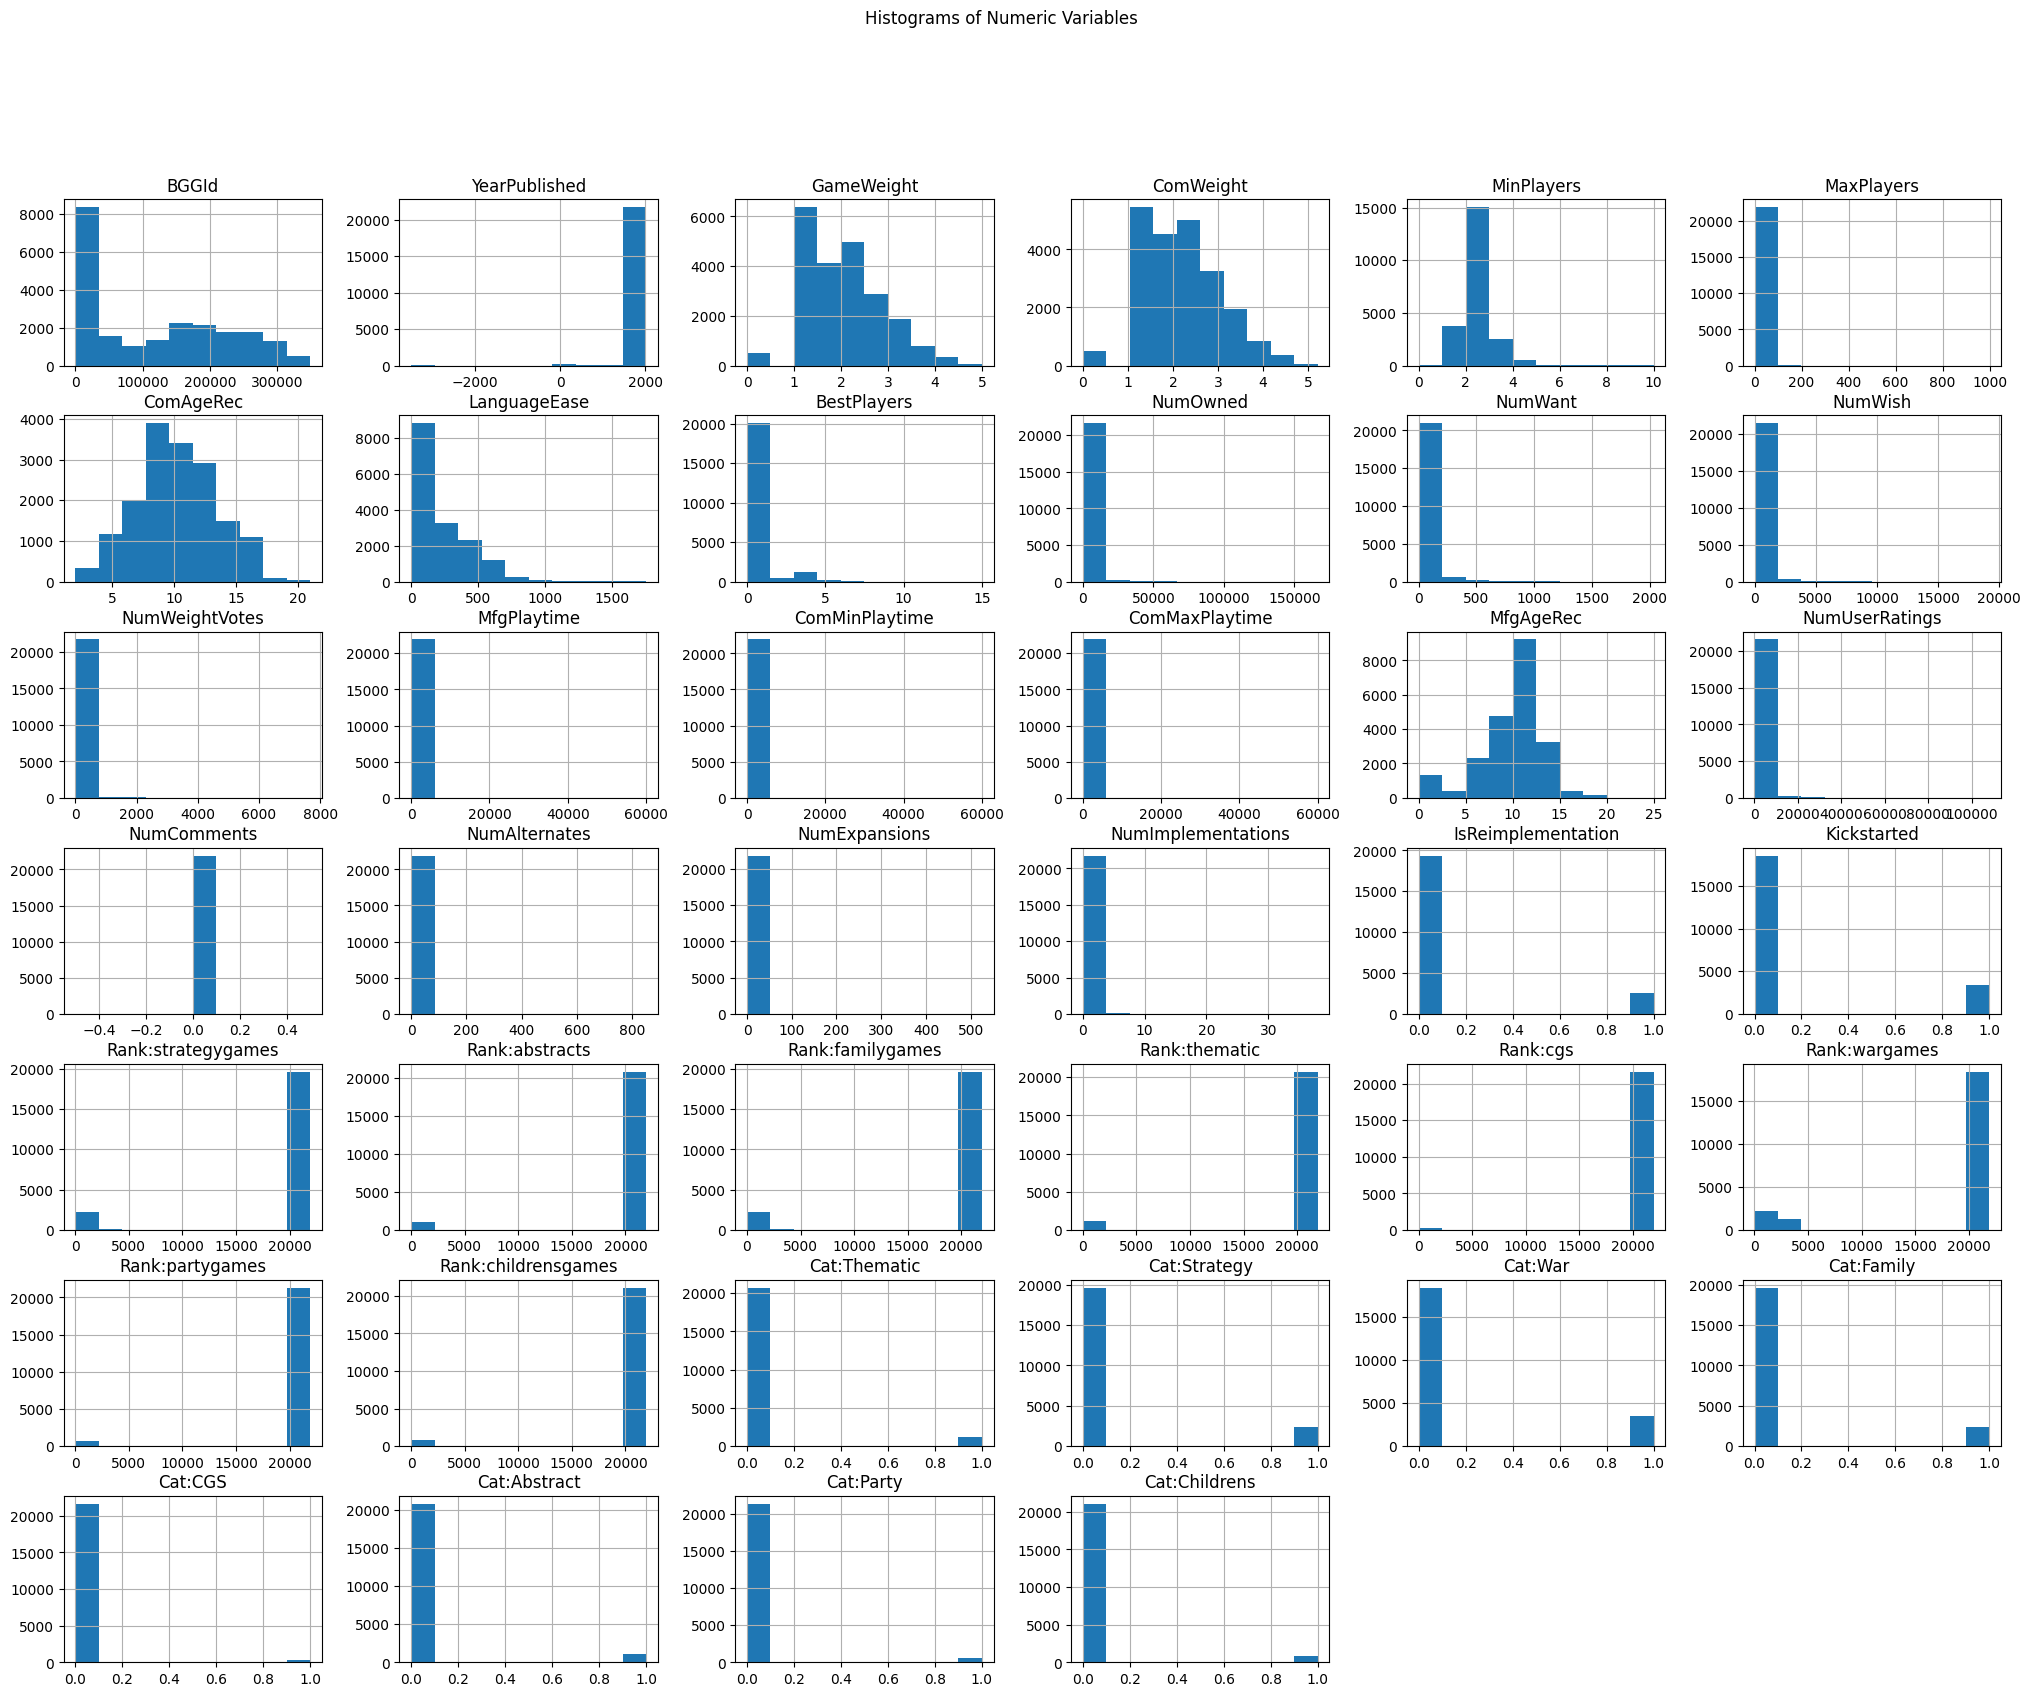

In [11]:
# Histograms for numeric columns
numeric_columns = df.select_dtypes(include=[float, int])
numeric_columns.hist(figsize=(25, 19))
plt.suptitle("Histograms of Numeric Variables")

plt.show()

In [12]:
# list of object dtype (text-like columns)
object_features = df.select_dtypes(include=[object])
object_features.columns

Index(['Name', 'Description', 'GoodPlayers', 'Family', 'ImagePath', 'Rating'], dtype='object')

In [13]:
text_columns = ['Name','Description','ImagePath']
categorical_columns = ['Rating','Family','GoodPlayers']

print("Text Columns:", text_columns)
print("Categorical Columns:", categorical_columns)

Text Columns: ['Name', 'Description', 'ImagePath']
Categorical Columns: ['Rating', 'Family', 'GoodPlayers']


In [14]:
text_columns       = ['Name','Description','ImagePath']
categorical_columns = ['Rating','Family']
special_columns    = ['GoodPlayers']


In [15]:
print("Text:", text_columns)
print("Categorical:", categorical_columns)
print("Special:", special_columns)

Text: ['Name', 'Description', 'ImagePath']
Categorical: ['Rating', 'Family']
Special: ['GoodPlayers']


In [16]:
# Subset of columns based on dtype
int_subset = df.select_dtypes(include=['int'])
float_subset = df.select_dtypes(include=['float'])
bool_subset = df.select_dtypes(include=['bool'])
object_subset = df.select_dtypes(include=['object'])

subsets = {"int" : int_subset, "float": float_subset, "bool": bool_subset, "object" : object_subset}

for t, subset in subsets.items():
    print(f"Type {t} Features:")
    print(subset.columns.tolist())
    print("\n")

Type int Features:
['BGGId', 'YearPublished', 'MinPlayers', 'MaxPlayers', 'BestPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'MfgPlaytime', 'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings', 'NumComments', 'NumAlternates', 'NumExpansions', 'NumImplementations', 'IsReimplementation', 'Kickstarted', 'Rank:strategygames', 'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs', 'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames', 'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS', 'Cat:Abstract', 'Cat:Party', 'Cat:Childrens']


Type float Features:
['GameWeight', 'ComWeight', 'ComAgeRec', 'LanguageEase']


Type bool Features:
[]


Type object Features:
['Name', 'Description', 'GoodPlayers', 'Family', 'ImagePath', 'Rating']




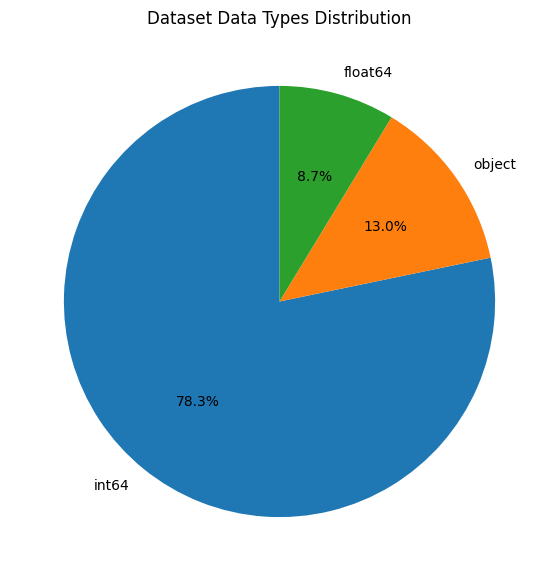

In [17]:
plt.figure(figsize=(7,7))
df.dtypes.value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Dataset Data Types Distribution')
plt.ylabel("")
plt.show()

#DUPLICATES IN ROW

In [18]:
# Load the dataset (update the path if needed)
df = pd.read_csv("DM1_game_dataset.csv")

# Find duplicates based on the combination of 'Name' and 'YearPublished'
duplicates = df[df.duplicated(subset=['Name', 'YearPublished'], keep=False)]

# Sort by name and year for easier reading
duplicates = duplicates.sort_values(by=['Name', 'YearPublished'])

# Display results
print(f"Total duplicates found: {duplicates.shape[0]}")

# Show the first 15 duplicate entries (only name and year for clarity)
duplicates[['Name', 'YearPublished']].head(15)


Total duplicates found: 12


,Name,YearPublished
8768,Blitzkrieg!: World War Two in 20 Minutes,2019
13421,Blitzkrieg!: World War Two in 20 Minutes,2019
2404,Cahoots,2018
3934,Cahoots,2018
7658,Chaos,2010
15761,Chaos,2010
7896,Columbus,1991
10065,Columbus,1991
13487,DIG,2017
16680,DIG,2017


In [19]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


#DUPLICATES IN COLUMNS


In [20]:
df.T[df.T.duplicated()]

,0,1,2,3,4,5,6,7,8,9,...,21915,21916,21917,21918,21919,21920,21921,21922,21923,21924
ComMaxPlaytime,30,20,150,20,20,30,0,90,90,5,...,180,20,20,60,20,15,20,45,30,180


In [21]:
same_cols = []
for col in df.columns:
    if df[col].equals(df['ComMaxPlaytime']) and col != 'ComMaxPlaytime':
        same_cols.append(col)
same_cols


['MfgPlaytime']

In [22]:
df.shape

(21925, 46)

In [23]:
# Drop MfgPlaytime because it duplicates ComMaxPlaytime
df = df.drop(columns=['MfgPlaytime'])

print("Dropped MfgPlaytime successfully.")
print("New shape:", df.shape)

Dropped MfgPlaytime successfully.
New shape: (21925, 45)


### Checking for duplicate columns

During the column comparison, it was found that the features **`ComMaxPlaytime`** and **`MfgPlaytime`** contain identical values across all rows.  
However, these two columns represent **different concepts**:
- `ComMaxPlaytime` → Community-reported maximum playtime  
- `MfgPlaytime` → Manufacturer-reported maximum playtime  

Even though their current numeric values are the same, they come from different data sources and may diverge in future updates.  
**For now, both columns are kept** to preserve their semantic meaning and maintain completeness in the dataset.


In [24]:
# final duplicate check

# check duplicate rows
print("duplicate rows:", df.duplicated().sum())

# check duplicate columns
dup_cols = df.T.duplicated()
print("duplicate columns:", df.columns[dup_cols].tolist())

duplicate rows: 0
duplicate columns: []


In [25]:

df.isin([0]).any().any()


np.True_

In [26]:
df.shape

(21925, 45)

Yes, some features do have zeros.

#CALCULATE THE ZEROS

In [27]:
# Conta gli zeri solo sulle colonne numeriche
num_cols = df.select_dtypes(include=np.number).columns

zero_counts = (df[num_cols] == 0).sum()
zero_pct = ((df[num_cols] == 0).sum() / len(df) * 100).round(2)

zero_summary = pd.DataFrame({
    "column": num_cols,
    "zero_count": zero_counts.values,
    "zero_pct": zero_pct.values
}).sort_values("zero_pct", ascending=False)

print("📊 Colonne con valori pari a 0:")
print(zero_summary[zero_summary["zero_count"] > 0].head(45))

📊 Colonne con valori pari a 0:
                column  zero_count  zero_pct
17         NumComments       21925    100.00
35             Cat:CGS       21622     98.62
37           Cat:Party       21285     97.08
38       Cat:Childrens       21044     95.98
36        Cat:Abstract       20810     94.91
31        Cat:Thematic       20701     94.42
8          BestPlayers       19944     90.96
34          Cat:Family       19609     89.44
32        Cat:Strategy       19606     89.42
21  IsReimplementation       19365     88.32
22         Kickstarted       18563     84.67
33             Cat:War       18395     83.90
20  NumImplementations       17052     77.77
19       NumExpansions       16337     74.51
18       NumAlternates       12967     59.14
10             NumWant        1938      8.84
15           MfgAgeRec        1325      6.04
14      ComMaxPlaytime         780      3.56
13      ComMinPlaytime         652      2.97
2           GameWeight         506      2.31
3            ComWeight  

In [28]:
df.shape

(21925, 45)

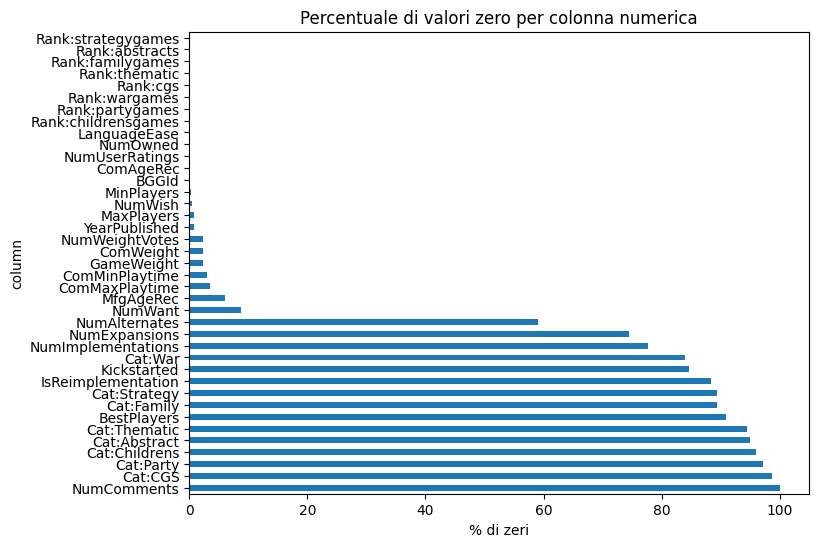

In [29]:
zero_summary.set_index("column")["zero_pct"].plot(kind="barh", figsize=(8,6))
plt.title("Percentuale di valori zero per colonna numerica")
plt.xlabel("% di zeri")
plt.show()


#DROP NumComments and BestPlayers

In [30]:
df.drop(columns=["NumComments"], inplace=True)
print("✅ Colonna 'NumComments' rimossa.")

✅ Colonna 'NumComments' rimossa.


In [31]:
df.shape

(21925, 44)

In [32]:
df.drop(columns=["BestPlayers"], inplace=True)
print("✅ Colonna 'BestPlayers' rimossa.")

✅ Colonna 'BestPlayers' rimossa.


In [33]:
df.shape

(21925, 43)

In [34]:
df_before = df.copy()

In [35]:
df.shape

(21925, 43)

#Imputation zeros

In [36]:
#per GameWeight, ComWeight, NumWeightVotes uso la Mediana in quando i dati sono skewed
for col in ["GameWeight", "ComWeight", "NumWeightVotes"]:
    median_value = df[col].median()
    df.loc[df[col] == 0, col] = median_value
    print(f"Imputata '{col}' con mediana ({median_value}).")

Imputata 'GameWeight' con mediana (1.9688).
Imputata 'ComWeight' con mediana (2.128).
Imputata 'NumWeightVotes' con mediana (9.0).


In [37]:
#MinPlayers con 1

df.loc[df["MinPlayers"] == 0, "MinPlayers"] = 1

In [38]:
#MaxPlayers con mediana per categoria
for cat in ["Cat:Strategy", "Cat:Family", "Cat:Party", "Cat:War"]:
    mask = df[cat] == 1
    median_val = df.loc[mask, "MaxPlayers"].median()
    df.loc[(df["MaxPlayers"] == 0) & mask, "MaxPlayers"] = median_val

In [39]:
#YearsPublished con mediana
df.loc[df["YearPublished"] == 0, "YearPublished"] = df["YearPublished"].median()

In [40]:
cols_to_check = [
    "GameWeight", "ComWeight", "NumWeightVotes",
     "MinPlayers", "MaxPlayers", "YearPublished"
]

for col in cols_to_check:
    before = df_before[col]
    after = df[col]

    # righe dove c'è stata una modifica
    mask = before != after

    changed = pd.DataFrame({
        "Before": before[mask],
        "After": after[mask]
    })

    print("\n========================================")
    print(f"   MODIFICHE EFFETTUATE SU: {col}")
    print("========================================")
    print(f"Totale valori modificati: {mask.sum()}")
    print(changed.head(10))     # mostra i primi 10



   MODIFICHE EFFETTUATE SU: GameWeight
Totale valori modificati: 506
     Before   After
58      0.0  1.9688
107     0.0  1.9688
111     0.0  1.9688
117     0.0  1.9688
153     0.0  1.9688
183     0.0  1.9688
234     0.0  1.9688
257     0.0  1.9688
263     0.0  1.9688
269     0.0  1.9688

   MODIFICHE EFFETTUATE SU: ComWeight
Totale valori modificati: 506
     Before  After
58      0.0  2.128
107     0.0  2.128
111     0.0  2.128
117     0.0  2.128
153     0.0  2.128
183     0.0  2.128
234     0.0  2.128
257     0.0  2.128
263     0.0  2.128
269     0.0  2.128

   MODIFICHE EFFETTUATE SU: NumWeightVotes
Totale valori modificati: 506
     Before  After
58        0      9
107       0      9
111       0      9
117       0      9
153       0      9
183       0      9
234       0      9
257       0      9
263       0      9
269       0      9

   MODIFICHE EFFETTUATE SU: MinPlayers
Totale valori modificati: 50
      Before  After
268        0      1
733        0      1
1104       0      1


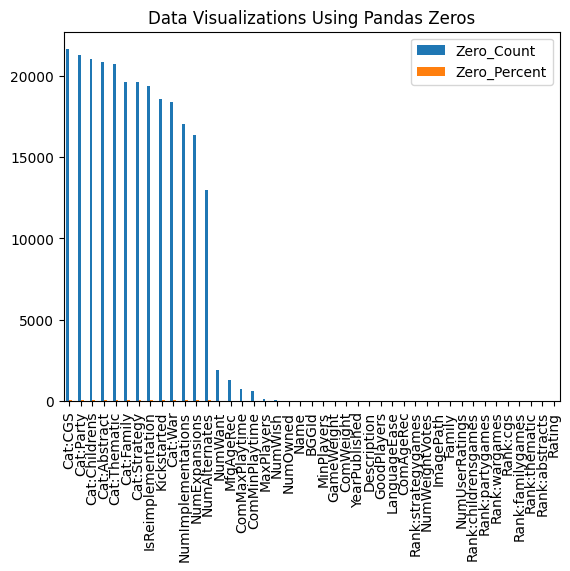

In [41]:
# Check how many zeros per column
zero_counts = (df == 0).sum().sort_values(ascending=False)

# Also show what % of the column are zeros
zero_percent = ((df == 0).sum() / len(df) * 100).sort_values(ascending=False)

# Combine results
zero_summary = pd.DataFrame({'Zero_Count': zero_counts, 'Zero_Percent': zero_percent})
zero_summary.plot(kind='bar')
plt.title('Data Visualizations Using Pandas Zeros')
plt.show()

In [42]:
df.shape

(21925, 43)

DATA CLEANING

#MISSING VALUES

HANDLING MISSING VALUES
For the data cleaning, the foremost step is to handle the missing values. It ensures not only the completion of the data but also the quality of the data analysis and findings

In [43]:
print('Number of features: {}'.format(df.shape[1]))
print('Numerical features: {}'.format(df.select_dtypes(['float','int']).shape[1]))
print('Missing values: {}\n'.format(df.isnull().sum().sum()))
df.head()

Number of features: 43
Numerical features: 37
Missing values: 26701



,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,NaN,NaN,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,NaN,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,NaN,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [44]:
def missing_values(df):
        # Total missing values
        mis_val = df.isnull().sum()

        # Percentage
        mis_val_percent = 100 * df.isnull().sum() / len(df)

        # Make a table with the results
        mis_val_table = pd.concat([mis_val, mis_val_percent], axis=1)

        mis_val_table_ren_columns = mis_val_table.rename(
        columns = {0 : 'Missing Values', 1 : '% of Total Values'})

        # Sort the table by percentage of missing descending
        mis_val_table_ren_columns = mis_val_table_ren_columns[
            mis_val_table_ren_columns.iloc[:,1] != 0].sort_values(
        '% of Total Values', ascending=False).round(1)

        # Print some summary information
        print ("Your selected dataframe has " + str(df.shape[1]) + " columns.\n"
            "There are " + str(mis_val_table_ren_columns.shape[0]) +
              " columns that have missing values.")

        # Return the dataframe with missing information
        return mis_val_table_ren_columns

missing_values_table = missing_values(df)
missing_values_table

Your selected dataframe has 43 columns.
There are 5 columns that have missing values.


,Missing Values,% of Total Values
Family,15262,69.6
LanguageEase,5891,26.9
ComAgeRec,5530,25.2
ImagePath,17,0.1
Description,1,0.0


STRATEGY:

Features having over 50% missing values will be dropped out from the dataset. Although that column is very important to study in our study but to avoid the imputational biasness and retain the reliability of the study's outcomes, features with over 50% missing values will have to be dropped off.

<Axes: >

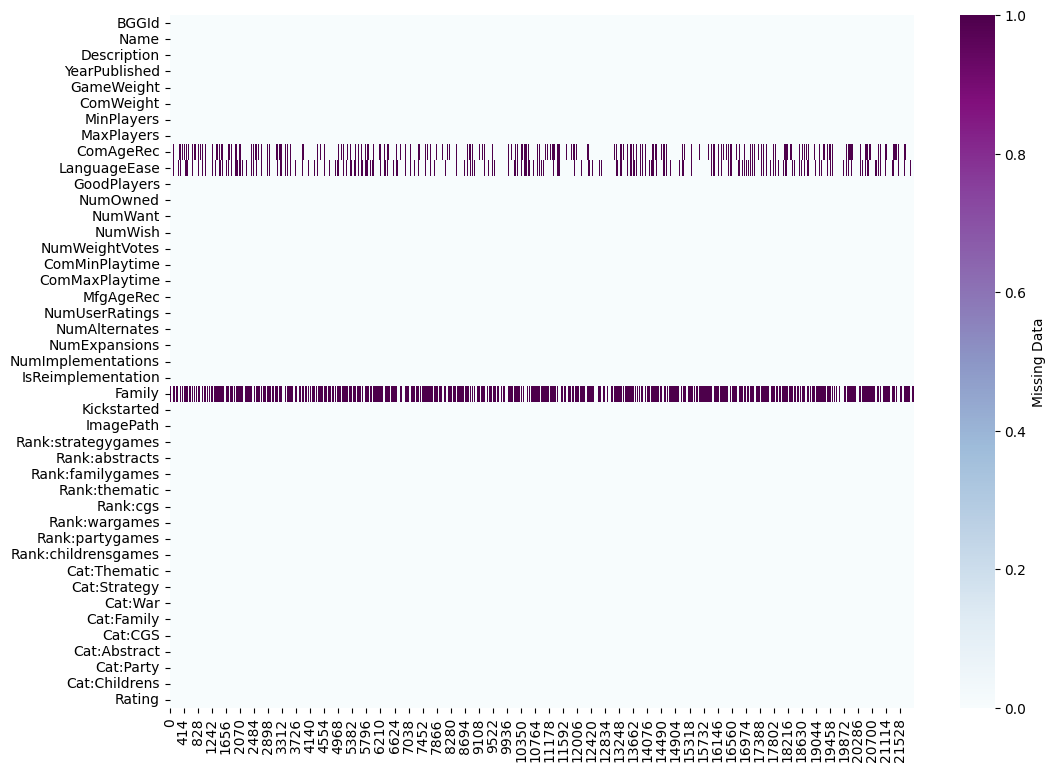

In [45]:
plt.figure(figsize=(12,9))
sns.heatmap(df.isna().transpose(),
            cmap="BuPu",
            cbar_kws={'label': 'Missing Data'})

First of all, let's do a copy of our dataframe. this will be necessary to compare values before and after handling the missing values

In [46]:
df = df.copy()
df_raw = df.copy()


In [47]:
df.shape

(21925, 43)

STRATEGY:

Features having over 50% missing values will be dropped out from the dataset. Although that column is very important to study in our study but to avoid the imputational biasness and retain the reliability of the study's outcomes, Family features will have to be dropped off.

In [48]:
df = df.drop(['Family'],axis=1)
df.isna().sum()

,0
BGGId,0
Name,0
Description,1
YearPublished,0
GameWeight,0
ComWeight,0
MinPlayers,0
MaxPlayers,0
ComAgeRec,5530
LanguageEase,5891


They are 3 imputation methods, Mean, Mode and Median. To choose which method to use, we are going to check the skewed distribution of each faetures. If the distribution is approximately symmetric, we will use the Mean method. If the distribution is skewed(positiely or negatively), we will use the Medain method. And use Mode for categorical  variables.



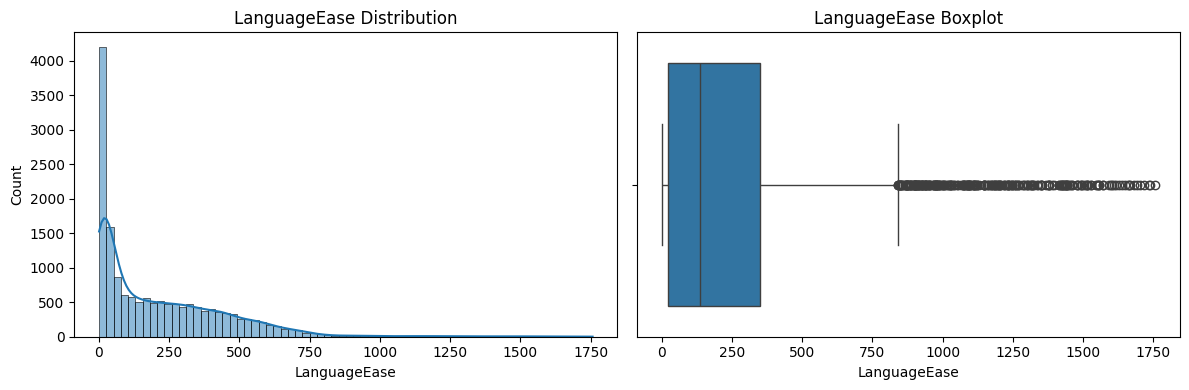

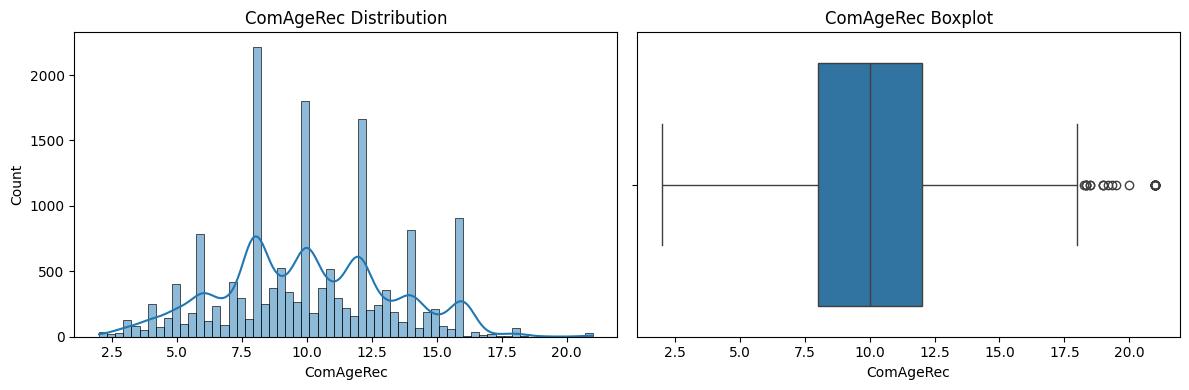

In [49]:
nums = ['LanguageEase','ComAgeRec']

for col in nums:
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'{col} Distribution')

    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'{col} Boxplot')

    plt.tight_layout()
    plt.show()


#Drop Family and imputation LanguafeEase and ComAgeRec

Since LanguageEase and ComAgeRec were heavily right–skewed with many outliers (as seen in the histograms and boxplots), we imputed their missing values using the median instead of the mean to avoid distortion of the variable's distribution.

In [50]:
### IMPUTATION USING MEDIAN

# 1) LanguageEase
lang_median = df['LanguageEase'].median()
df['LanguageEase'] = df['LanguageEase'].fillna(lang_median)

# 2) ComAgeRec
age_median = df['ComAgeRec'].median()
df['ComAgeRec'] = df['ComAgeRec'].fillna(age_median)

# verify no missing left in these 2 columns
print(df[['LanguageEase','ComAgeRec']].isna().sum())

LanguageEase    0
ComAgeRec       0
dtype: int64


In [51]:
df.isna().sum().sum()

np.int64(18)

In [52]:
df['ImagePath'] = df['ImagePath'].fillna('Unknown')
df['Description'] = df['Description'].fillna('Unknown')

# check again
print("Total missing values:", df.isna().sum().sum())

Total missing values: 0


In [53]:
df.isna().sum().sum()


np.int64(0)

Missing values: We found five columns with NaNs. Family had ~69.6% missing and was removed to avoid heavy imputation bias. LanguageEase and ComAgeRec were right-skewed / with outliers, so we imputed with the median (robust to skewness and outliers). ImagePath (17 NaNs) and Description (1 NaN) were filled with the string “Unknown” because they are text/identifier fields. After these steps, the dataset contained 0 missing values. We also verified there are no duplicate rows, no duplicate column names, and no columns that are exact duplicates of others.

In [54]:
print("Before cleaning:")
print(df_raw.shape)
print("Missing values before:", df_raw.isna().sum().sum())

print("\nAfter cleaning:")
print(df.shape)
print("Missing values after:", df.isna().sum().sum())

print("\nColumns removed during cleaning:", set(df_raw.columns) - set(df.columns))

Before cleaning:
(21925, 43)
Missing values before: 26701

After cleaning:
(21925, 42)
Missing values after: 0

Columns removed during cleaning: {'Family'}


In [55]:

df_clean = df.copy()

summary = pd.DataFrame({
    '': ['Rows','Columns','Missing values'],
    'Before': [df_raw.shape[0], df_raw.shape[1], int(df_raw.isna().sum().sum())],
    'After' : [df_clean.shape[0], df_clean.shape[1], int(df_clean.isna().sum().sum())],
})
display(summary)

print("Columns removed during cleaning:", set(df_raw.columns) - set(df_clean.columns))


,,Before,After
0,Rows,21925,21925
1,Columns,43,42
2,Missing values,26701,0


Columns removed during cleaning: {'Family'}


In [56]:
# === 3) Save the cleaned dataset (CSV + Parquet) ===
df_clean.to_csv('DM1_games_clean.csv', index=False)
df_clean.to_parquet('DM1_games_clean.parquet', index=False)

# Small metadata JSON to keep the audit trail
from datetime import datetime
import json

meta = {
    'created_at_utc': datetime.utcnow().isoformat() + 'Z',
    'rows': df_clean.shape[0],
    'cols': df_clean.shape[1],
    'cols_removed': sorted(list(set(df_raw.columns) - set(df_clean.columns))),
    'missing_before': int(df_raw.isna().sum().sum()),
    'missing_after' : int(df_clean.isna().sum().sum())
}
with open('DM1_clean_meta.json','w') as f:
    json.dump(meta, f, indent=2)
print(meta)

{'created_at_utc': '2026-01-17T14:01:44.212369Z', 'rows': 21925, 'cols': 42, 'cols_removed': ['Family'], 'missing_before': 26701, 'missing_after': 0}


In [57]:
# (Optional – Colab) Download the files to your computer
from google.colab import files
files.download('DM1_games_clean.csv')
files.download('DM1_games_clean.parquet')
files.download('DM1_clean_meta.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [58]:
df = pd.read_csv('DM1_games_clean.csv')
df.head()

,BGGId,Name,Description,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,...,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens,Rating
0,140386,Assassin's Creed: Arena,game description publisherin assassins creed a...,2014,1.8333,2.0512,2,4,8.0,213.0,...,21926,0,0,0,0,0,0,0,0,Low
1,344114,Bag of Chips,bag chip party game face crucial choice score ...,2021,1.0000,1.2256,2,5,8.0,36.0,...,21926,0,0,0,0,0,0,0,0,Medium
2,319196,Gùgōng: Deluxe Big Box,big box contain component gugravegng deluxe ed...,2020,3.6667,3.8190,1,5,10.0,138.0,...,21926,0,0,0,0,0,0,0,0,High
3,11404,LetterFlip,publisherthe reveal game secret wordsletterfli...,2004,1.3077,1.4216,2,2,7.0,138.0,...,21926,0,0,0,0,0,0,0,0,Low
4,281020,Treasures of Cibola,rescue mayan treasure easy task ...,2019,1.5000,1.6230,2,4,10.0,7.0,...,21926,0,0,0,0,0,0,0,0,Medium


In [59]:
df.shape


(21925, 42)

In [60]:
df.info()
df.describe(include='all').T
df.nunique().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21925 entries, 0 to 21924
Data columns (total 42 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   BGGId                21925 non-null  int64  
 1   Name                 21925 non-null  object 
 2   Description          21925 non-null  object 
 3   YearPublished        21925 non-null  int64  
 4   GameWeight           21925 non-null  float64
 5   ComWeight            21925 non-null  float64
 6   MinPlayers           21925 non-null  int64  
 7   MaxPlayers           21925 non-null  int64  
 8   ComAgeRec            21925 non-null  float64
 9   LanguageEase         21925 non-null  float64
 10  GoodPlayers          21925 non-null  object 
 11  NumOwned             21925 non-null  int64  
 12  NumWant              21925 non-null  int64  
 13  NumWish              21925 non-null  int64  
 14  NumWeightVotes       21925 non-null  int64  
 15  ComMinPlaytime       21925 non-null 

,0
BGGId,21925
ImagePath,21905
Description,21904
Name,21521
ComWeight,14382
NumOwned,4262
GameWeight,3920
LanguageEase,3794
Rank:wargames,3531
NumUserRatings,3130


#CORRELATION MATRIX

In [61]:
# Select only numerical columns for correlation analysis
df_numeric = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
matrix = df_numeric.corr()

# Print the correlation matrix
print(matrix)

                        BGGId  YearPublished  GameWeight  ComWeight  \
BGGId                1.000000       0.138350   -0.032174  -0.032926   
YearPublished        0.138350       1.000000    0.004619   0.005057   
GameWeight          -0.032174       0.004619    1.000000   0.997383   
ComWeight           -0.032926       0.005057    0.997383   1.000000   
MinPlayers          -0.134025      -0.006260   -0.178575  -0.178226   
MaxPlayers           0.017028       0.006258   -0.085021  -0.084752   
ComAgeRec           -0.043285       0.028999    0.574935   0.573381   
LanguageEase         0.084821       0.023118    0.015126   0.015063   
NumOwned             0.003861      -0.012742    0.081195   0.080783   
NumWant              0.066877       0.021838    0.244923   0.244310   
NumWish              0.092643       0.017714    0.190428   0.189919   
NumWeightVotes      -0.100408      -0.038873    0.115257   0.114292   
ComMinPlaytime      -0.053541      -0.004246    0.131151   0.130735   
ComMax

In [62]:
# Select only numerical columns for correlation analysis
df_numeric = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
matrix = df_numeric.corr()

# Print the correlation matrix
print(matrix)

                        BGGId  YearPublished  GameWeight  ComWeight  \
BGGId                1.000000       0.138350   -0.032174  -0.032926   
YearPublished        0.138350       1.000000    0.004619   0.005057   
GameWeight          -0.032174       0.004619    1.000000   0.997383   
ComWeight           -0.032926       0.005057    0.997383   1.000000   
MinPlayers          -0.134025      -0.006260   -0.178575  -0.178226   
MaxPlayers           0.017028       0.006258   -0.085021  -0.084752   
ComAgeRec           -0.043285       0.028999    0.574935   0.573381   
LanguageEase         0.084821       0.023118    0.015126   0.015063   
NumOwned             0.003861      -0.012742    0.081195   0.080783   
NumWant              0.066877       0.021838    0.244923   0.244310   
NumWish              0.092643       0.017714    0.190428   0.189919   
NumWeightVotes      -0.100408      -0.038873    0.115257   0.114292   
ComMinPlaytime      -0.053541      -0.004246    0.131151   0.130735   
ComMax

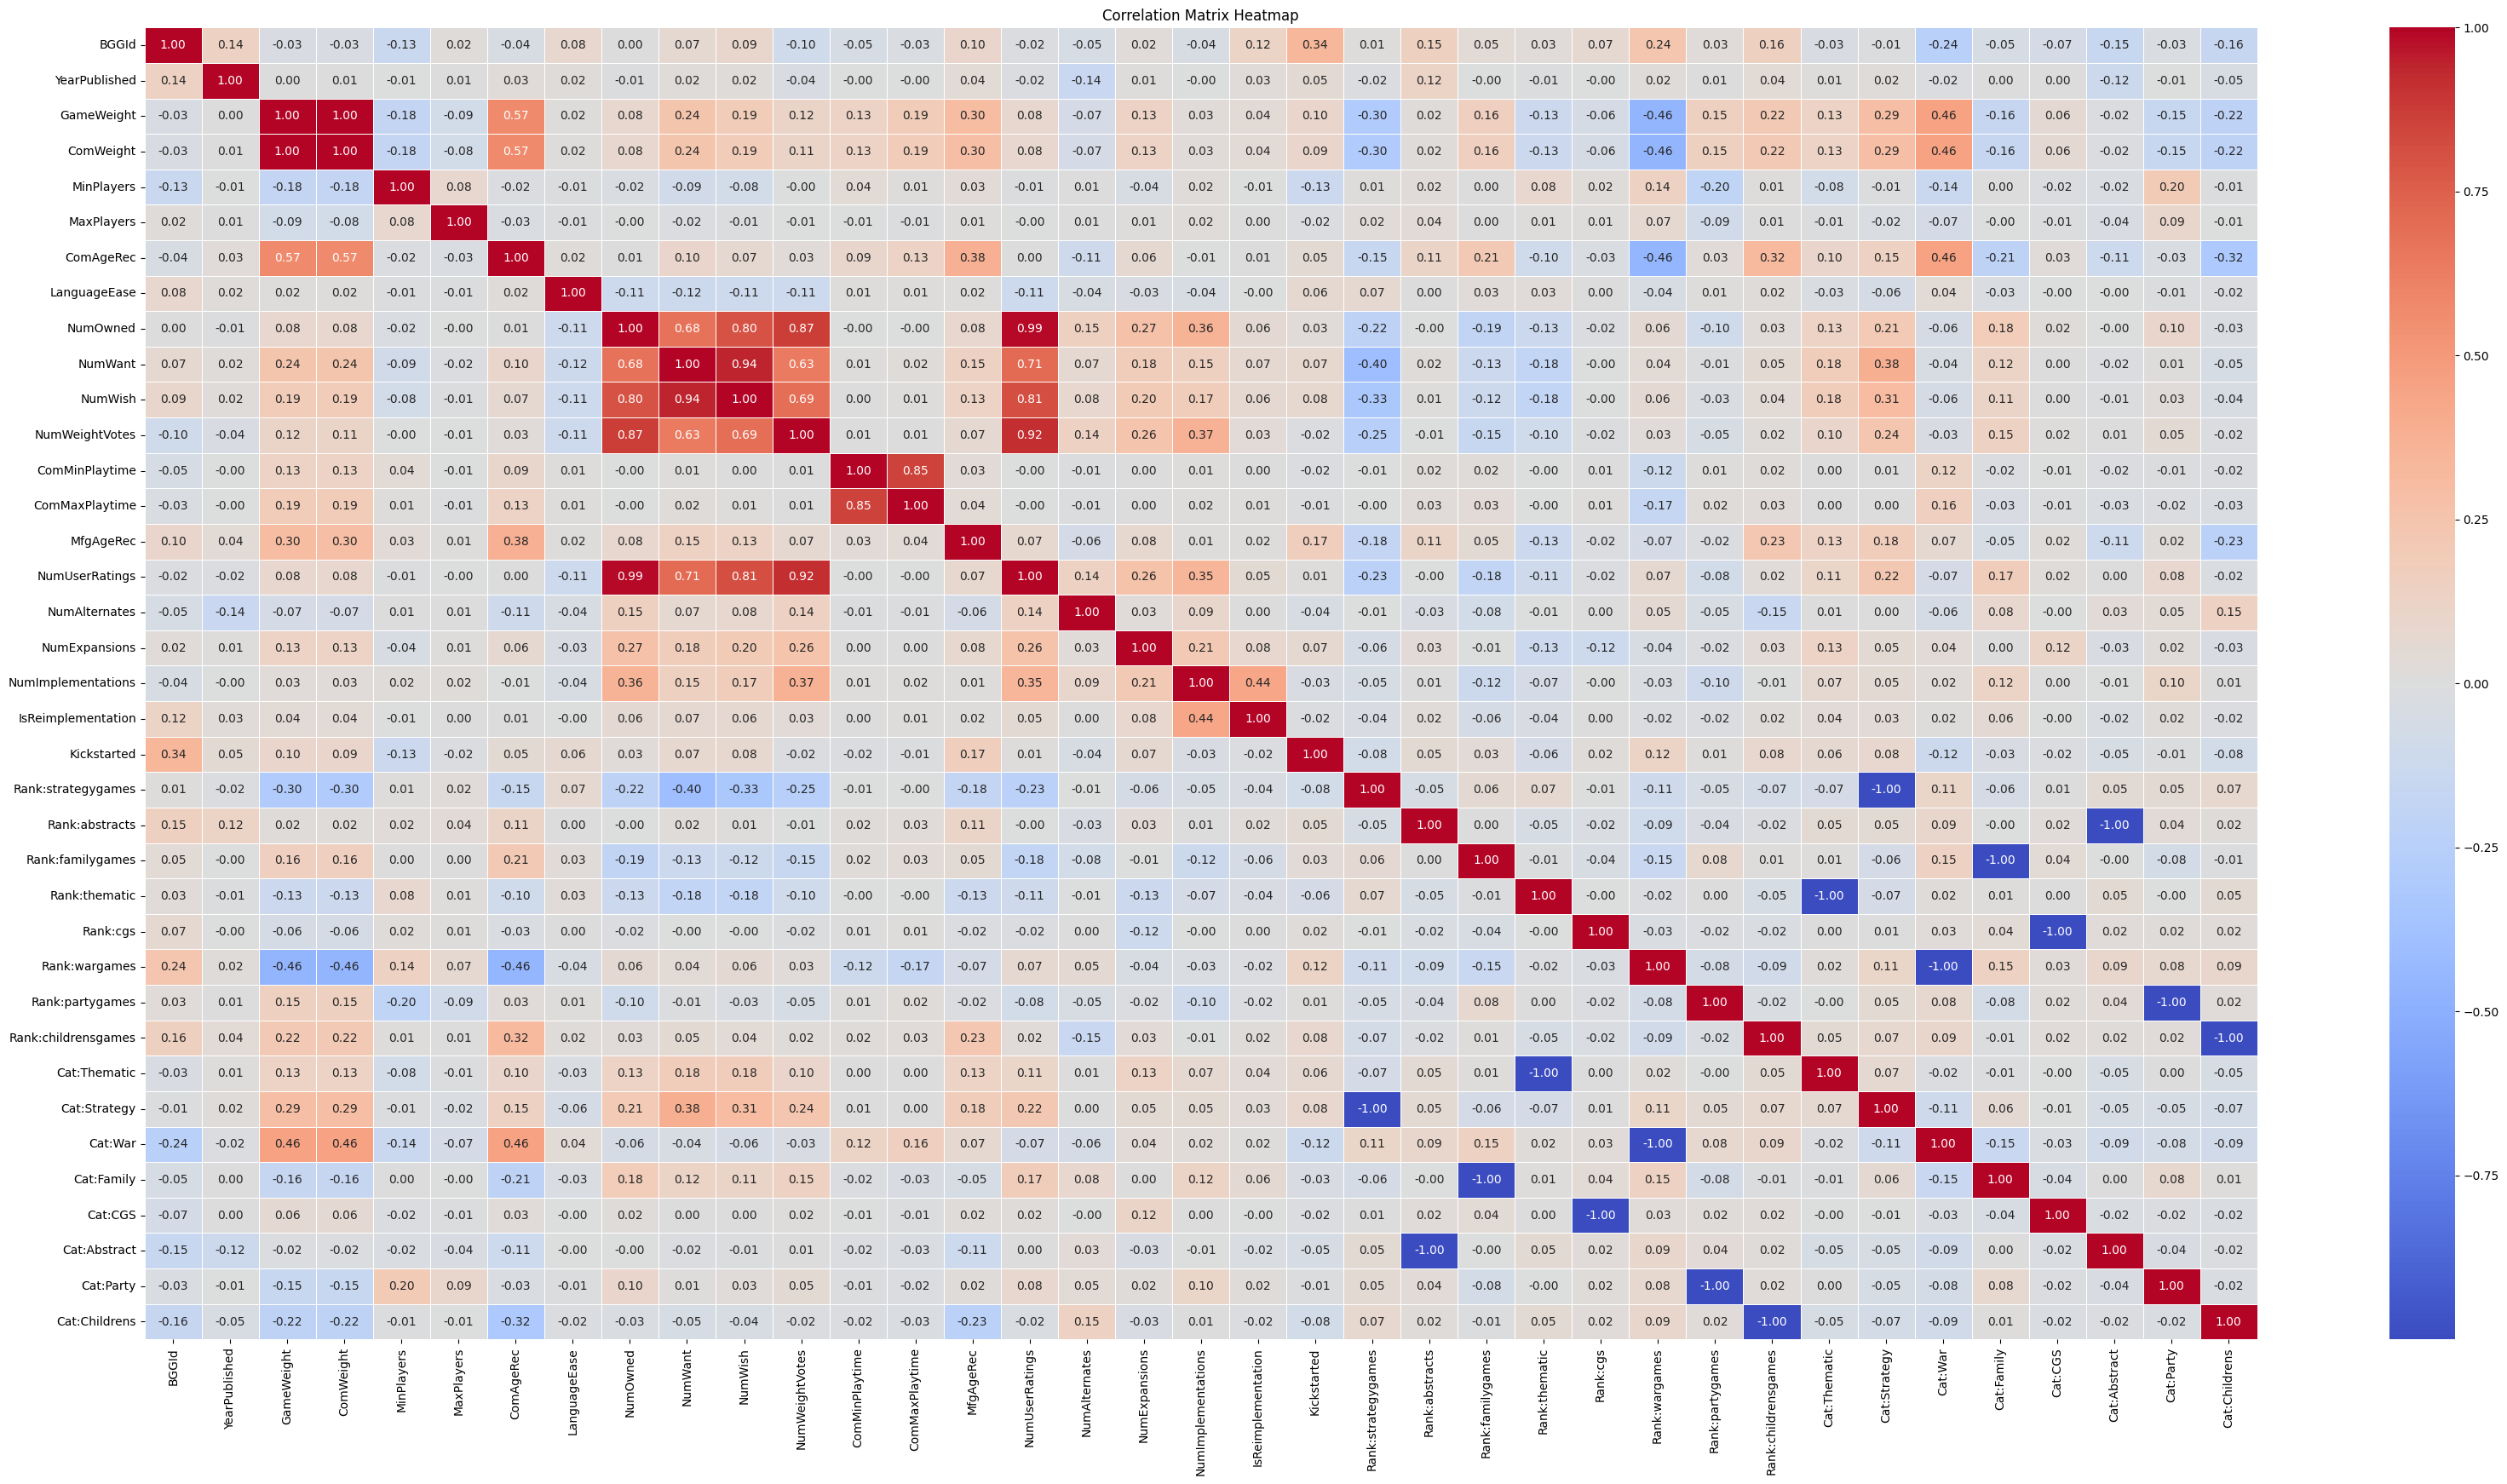

In [63]:
# Plotting the correlation matrix as a heatmap
plt.figure(figsize=(40,20))
sns.heatmap(matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

#IQR method

In [64]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

outlier_percent = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    outlier_percent[col] = (len(outliers) / len(df)) * 100

pd.Series(outlier_percent).sort_values(ascending=False)


,0
MinPlayers,31.407070
NumImplementations,22.225770
Rank:wargames,16.100342
Cat:War,16.100342
NumAlternates,15.858609
Kickstarted,15.334094
NumUserRatings,14.184721
NumWish,13.819840
NumWeightVotes,13.400228
NumWant,13.272520


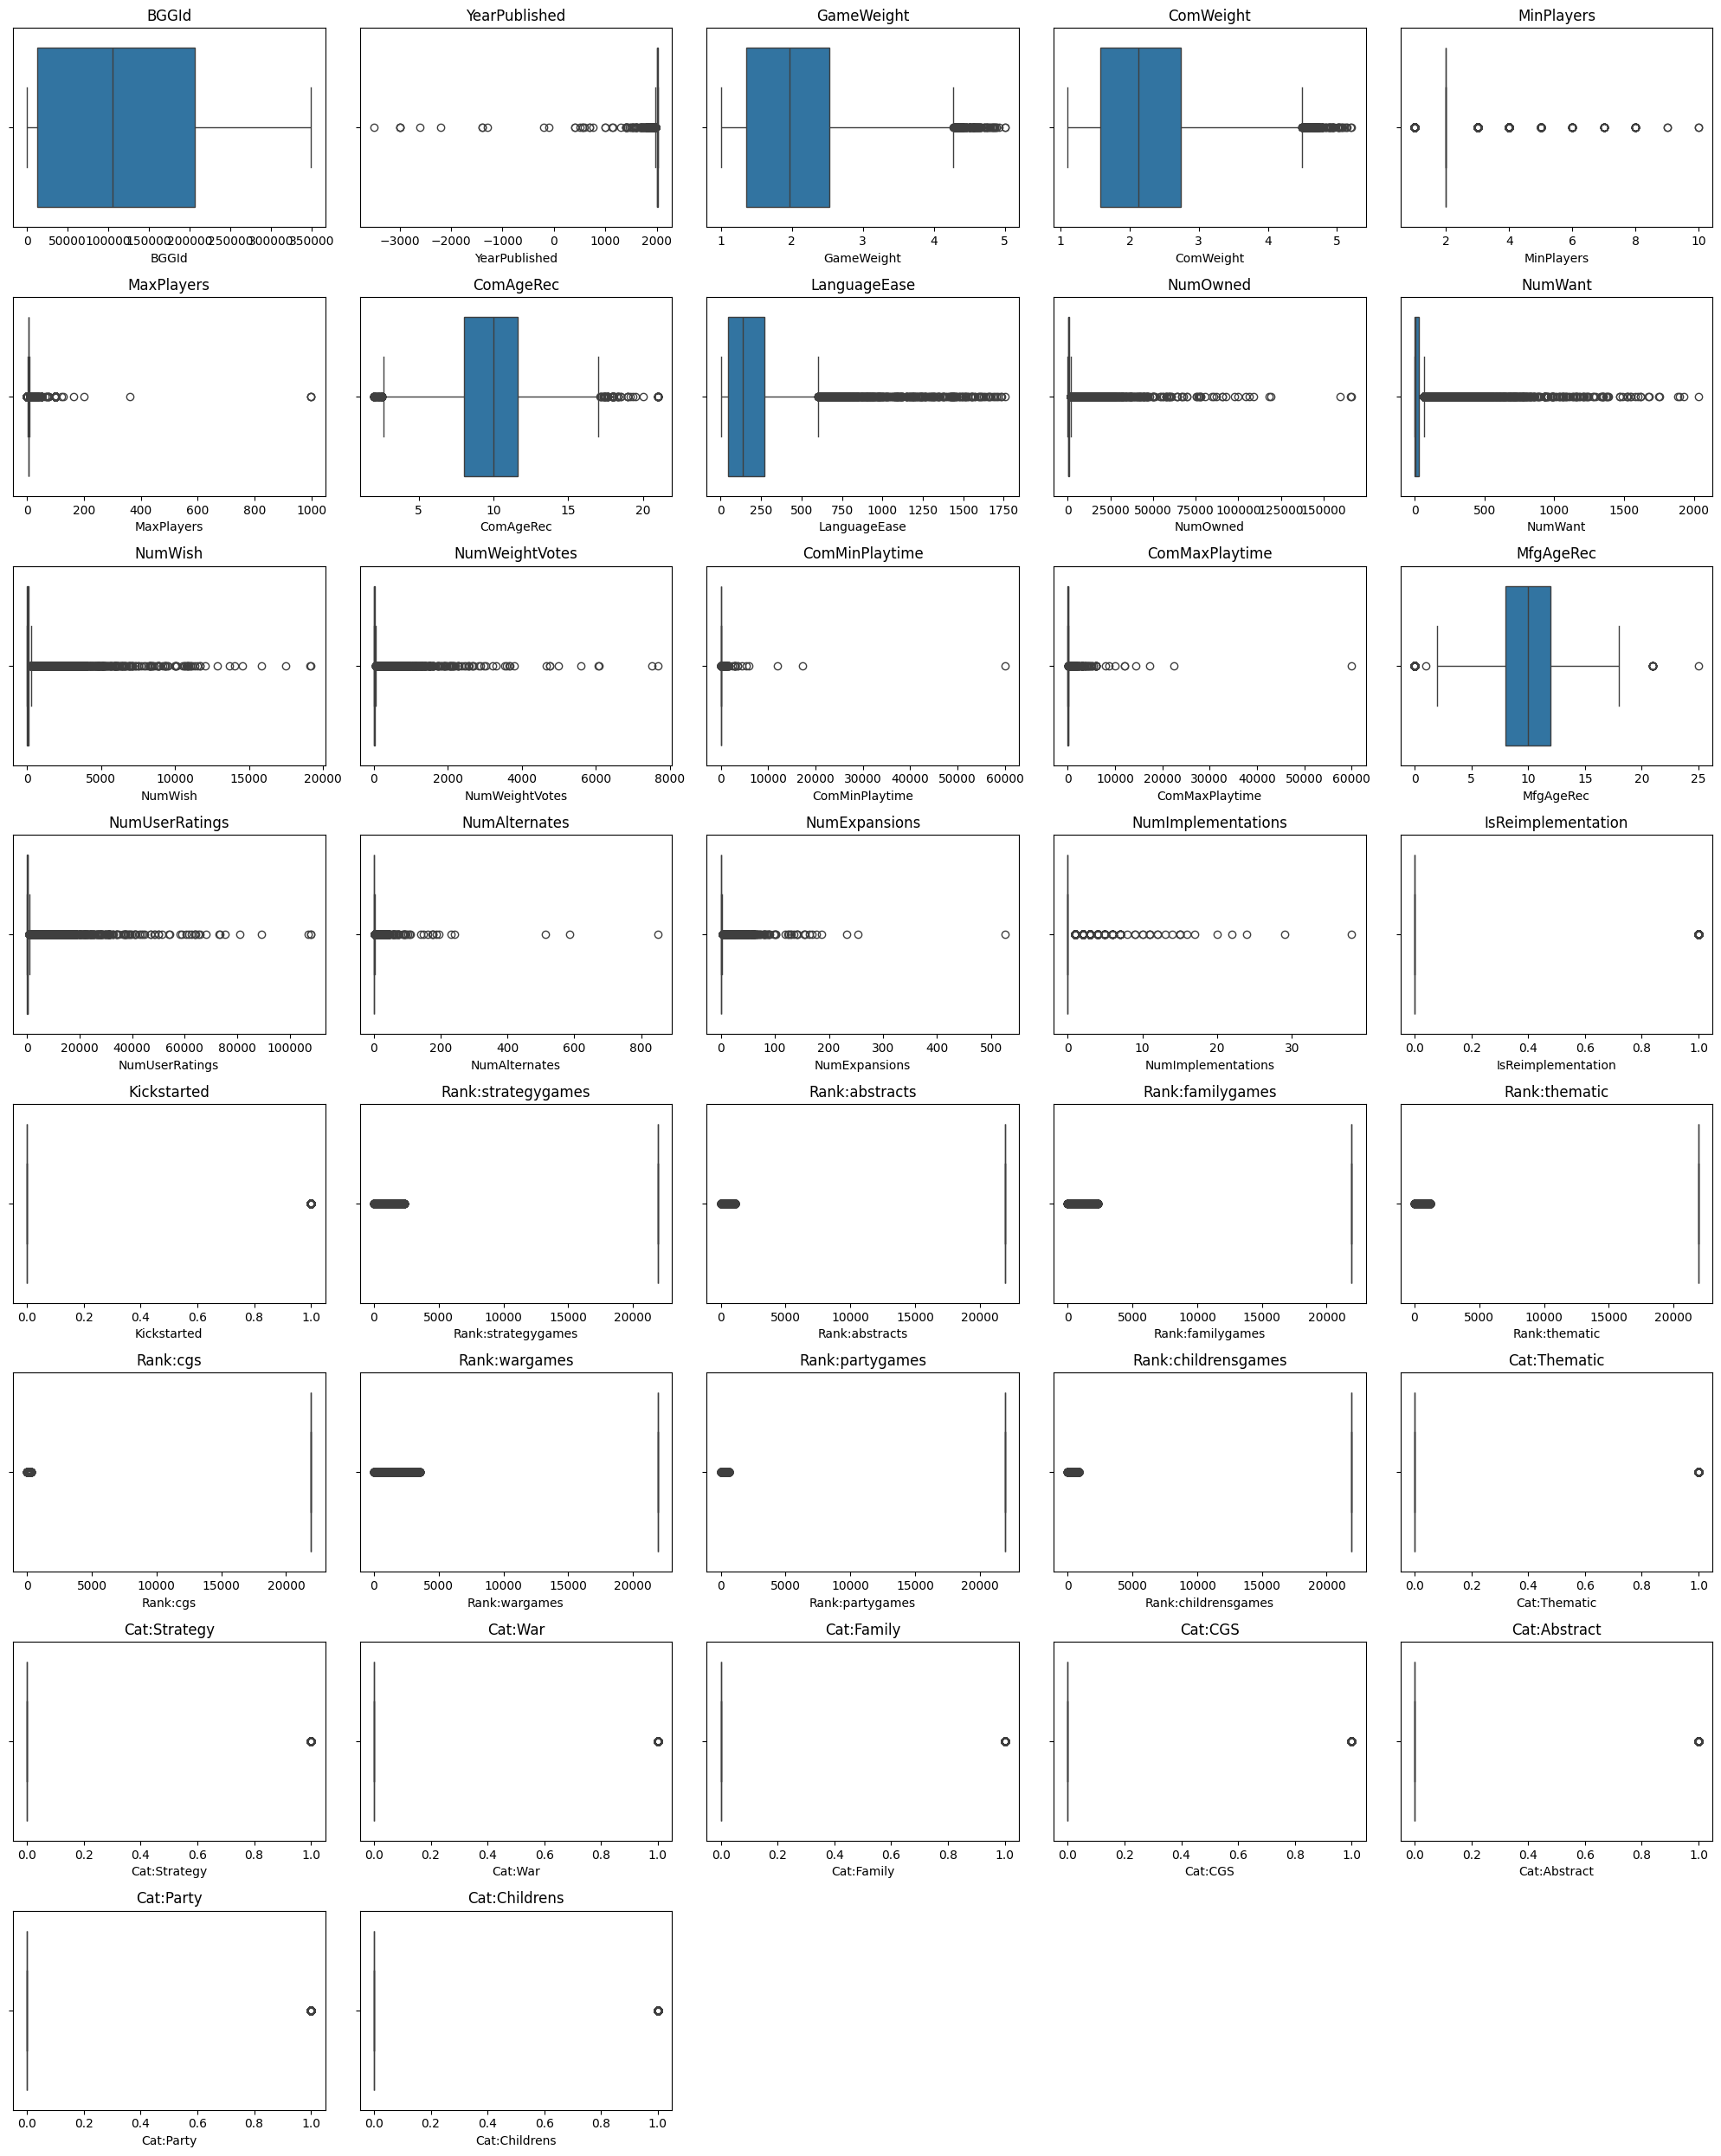

In [65]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns

plt.figure(figsize=(20, 25))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(8, 5, i)   # adjust grid based on number of features
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()


#LOG TRASFORMATION

In [66]:
# compute skewness of numeric columns
numeric_cols = df.select_dtypes(include=['float64','int64']).columns
skew_df = df[numeric_cols].skew().sort_values(ascending=False)
skew_df


,0
ComMinPlaytime,116.207073
ComMaxPlaytime,74.739212
NumAlternates,52.601012
MaxPlayers,42.399808
NumExpansions,24.951409
NumWeightVotes,15.324328
NumUserRatings,12.586978
NumOwned,12.517373
NumImplementations,12.157622
NumWish,9.350407


In [67]:
# Selecting top 6 highly skewed columns for log-transform
top_skew_cols = [
    'ComMinPlaytime',
    'NumAlternates',
    'MaxPlayers',
    'NumExpansions',
    'NumWeightVotes'
]
top_skew_cols


['ComMinPlaytime',
 'NumAlternates',
 'MaxPlayers',
 'NumExpansions',
 'NumWeightVotes']

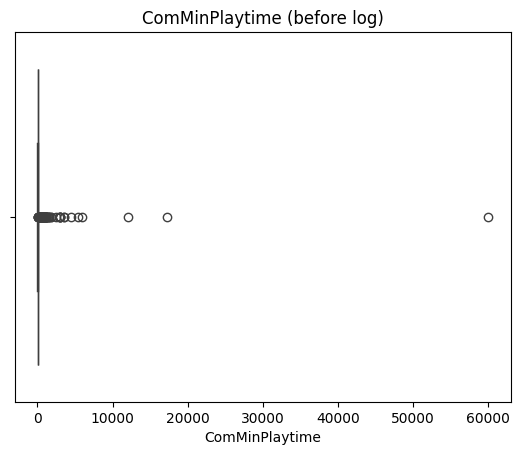

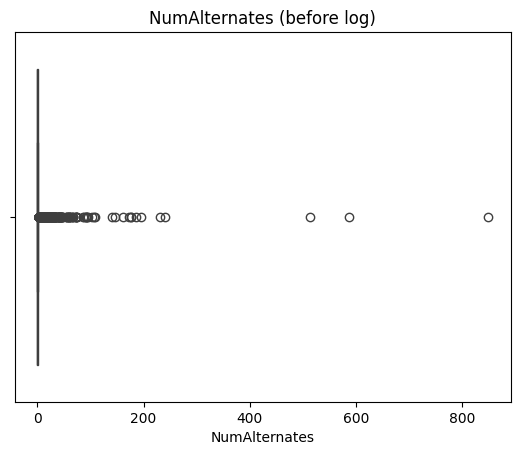

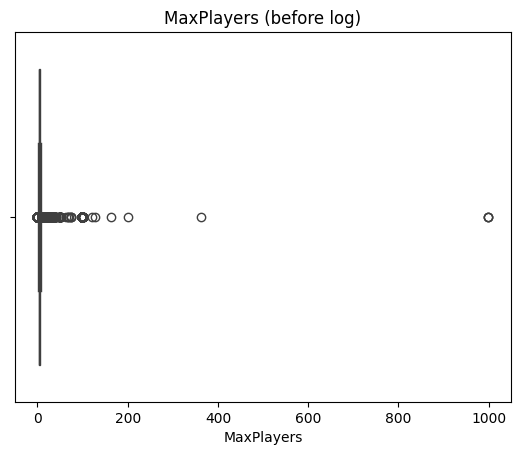

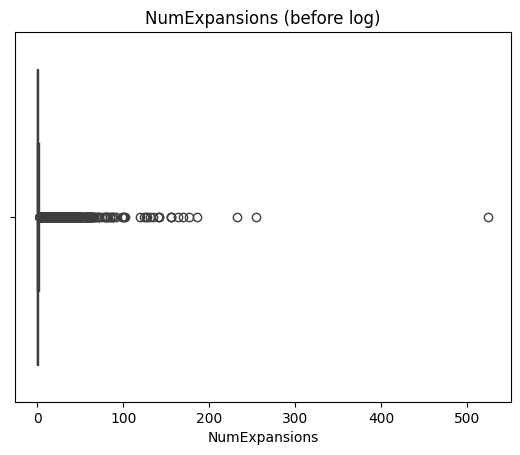

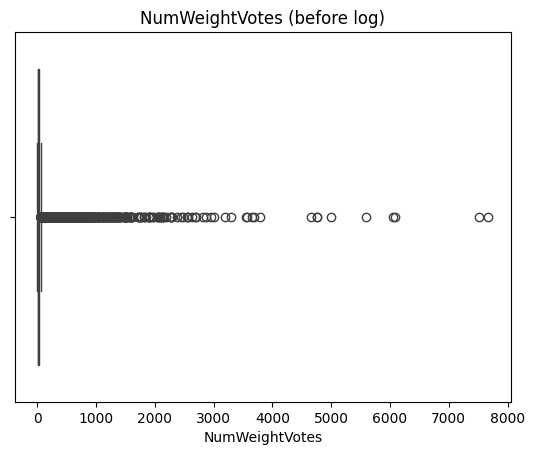

In [68]:
# before log
for col in top_skew_cols:
    sns.boxplot(x=df[col])
    plt.title(col + " (before log)")
    plt.show()

In [69]:
df[top_skew_cols] = df[top_skew_cols].apply(np.log1p)


In [70]:
df[top_skew_cols].skew().sort_values(ascending=False)


,0
NumExpansions,2.663103
MaxPlayers,1.672529
NumAlternates,1.626405
NumWeightVotes,1.030793
ComMinPlaytime,-0.677991


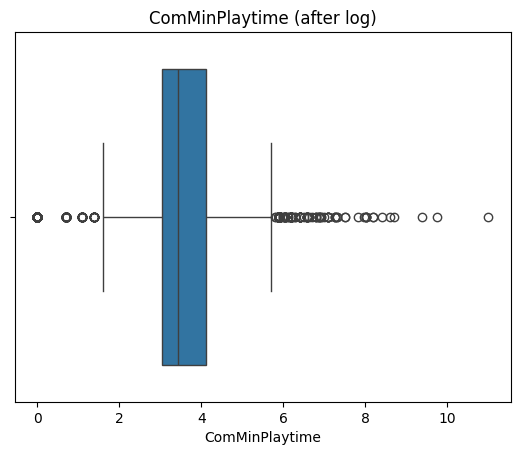

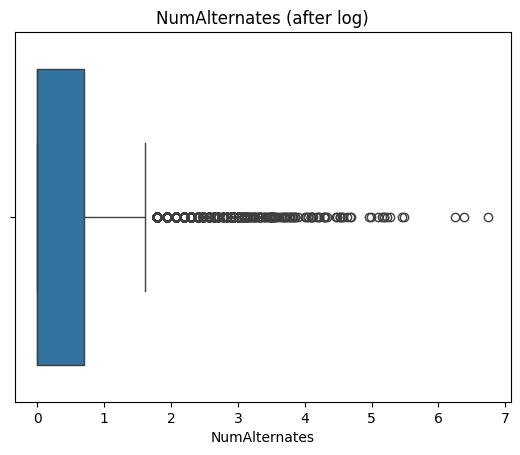

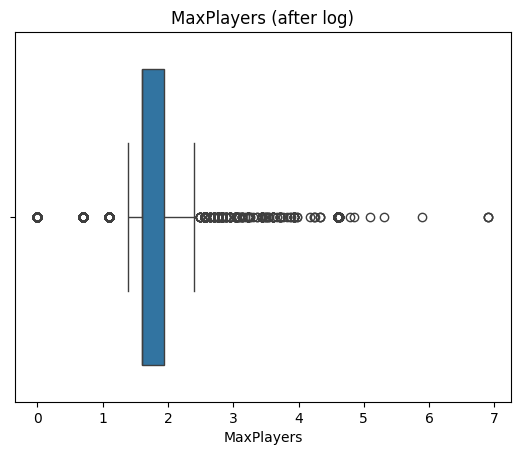

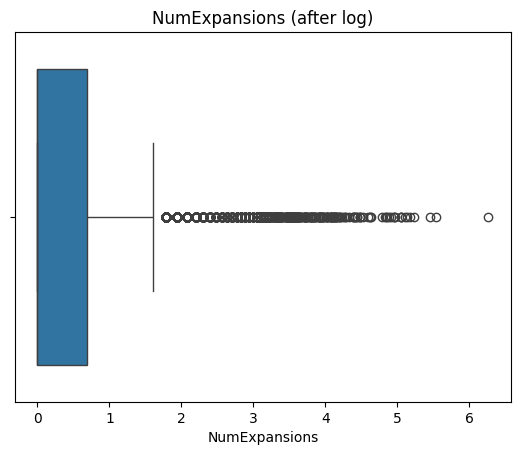

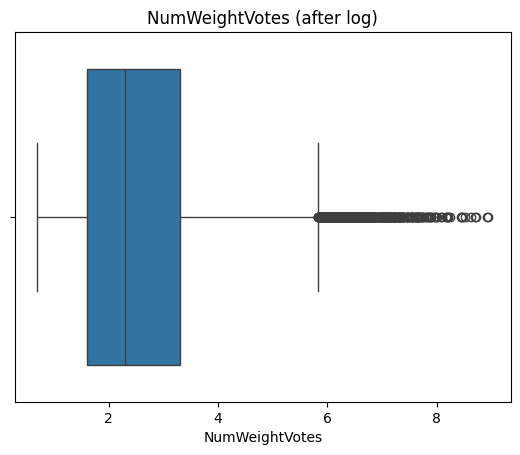

In [71]:
# after log
for col in top_skew_cols:
    sns.boxplot(x=df[col])
    plt.title(col + " (after log)")
    plt.show()


#CORRELATION MATRIX 2

In [72]:
num_df = df.select_dtypes(include=['int64','float64'])
num_df.corr()


,BGGId,YearPublished,GameWeight,ComWeight,MinPlayers,MaxPlayers,ComAgeRec,LanguageEase,NumOwned,NumWant,...,Rank:partygames,Rank:childrensgames,Cat:Thematic,Cat:Strategy,Cat:War,Cat:Family,Cat:CGS,Cat:Abstract,Cat:Party,Cat:Childrens
BGGId,1.000000,0.138350,-0.032174,-0.032926,-0.134025,0.061936,-0.043285,0.084821,0.003861,0.066877,...,0.029518,0.156249,-0.032780,-0.011922,-0.244953,-0.049418,-0.066902,-0.154353,-0.030082,-0.156850
YearPublished,0.138350,1.000000,0.004619,0.005057,-0.006260,0.037254,0.028999,0.023118,-0.012742,0.021838,...,0.005657,0.044601,0.009953,0.019528,-0.017319,0.003898,0.002092,-0.124235,-0.005856,-0.045415
GameWeight,-0.032174,0.004619,1.000000,0.997383,-0.178575,-0.244429,0.574935,0.015126,0.081195,0.244923,...,0.150625,0.217933,0.126988,0.294727,0.457173,-0.160049,0.058122,-0.017420,-0.150622,-0.218012
ComWeight,-0.032926,0.005057,0.997383,1.000000,-0.178226,-0.244248,0.573381,0.015063,0.080783,0.244310,...,0.150293,0.216966,0.125186,0.293852,0.456980,-0.159818,0.058158,-0.017264,-0.150291,-0.217039
MinPlayers,-0.134025,-0.006260,-0.178575,-0.178226,1.000000,0.296356,-0.018460,-0.014269,-0.023715,-0.091337,...,-0.197914,0.013659,-0.078466,-0.009552,-0.140306,0.000585,-0.016418,-0.024055,0.197601,-0.013662
MaxPlayers,0.061936,0.037254,-0.244429,-0.244248,0.296356,1.000000,-0.119386,-0.031561,0.026136,-0.009081,...,-0.200963,-0.014643,0.013310,-0.002432,-0.318047,0.050416,-0.047963,-0.124978,0.201021,0.014543
ComAgeRec,-0.043285,0.028999,0.574935,0.573381,-0.018460,-0.119386,1.000000,0.023121,0.006556,0.097246,...,0.026163,0.315547,0.098689,0.148080,0.455886,-0.211761,0.030778,-0.113123,-0.026013,-0.315345
LanguageEase,0.084821,0.023118,0.015126,0.015063,-0.014269,-0.031561,0.023121,1.000000,-0.110630,-0.122145,...,0.008347,0.023191,-0.026491,-0.062297,0.040202,-0.025051,-0.003304,-0.002498,-0.008257,-0.023432
NumOwned,0.003861,-0.012742,0.081195,0.080783,-0.023715,0.026136,0.006556,-0.110630,1.000000,0.677557,...,-0.096833,0.026857,0.128070,0.208032,-0.062402,0.184430,0.019432,-0.000839,0.096054,-0.026954
NumWant,0.066877,0.021838,0.244923,0.244310,-0.091337,-0.009081,0.097246,-0.122145,0.677557,1.000000,...,-0.010844,0.049293,0.178345,0.383135,-0.044817,0.120759,0.001345,-0.020505,0.010201,-0.049583


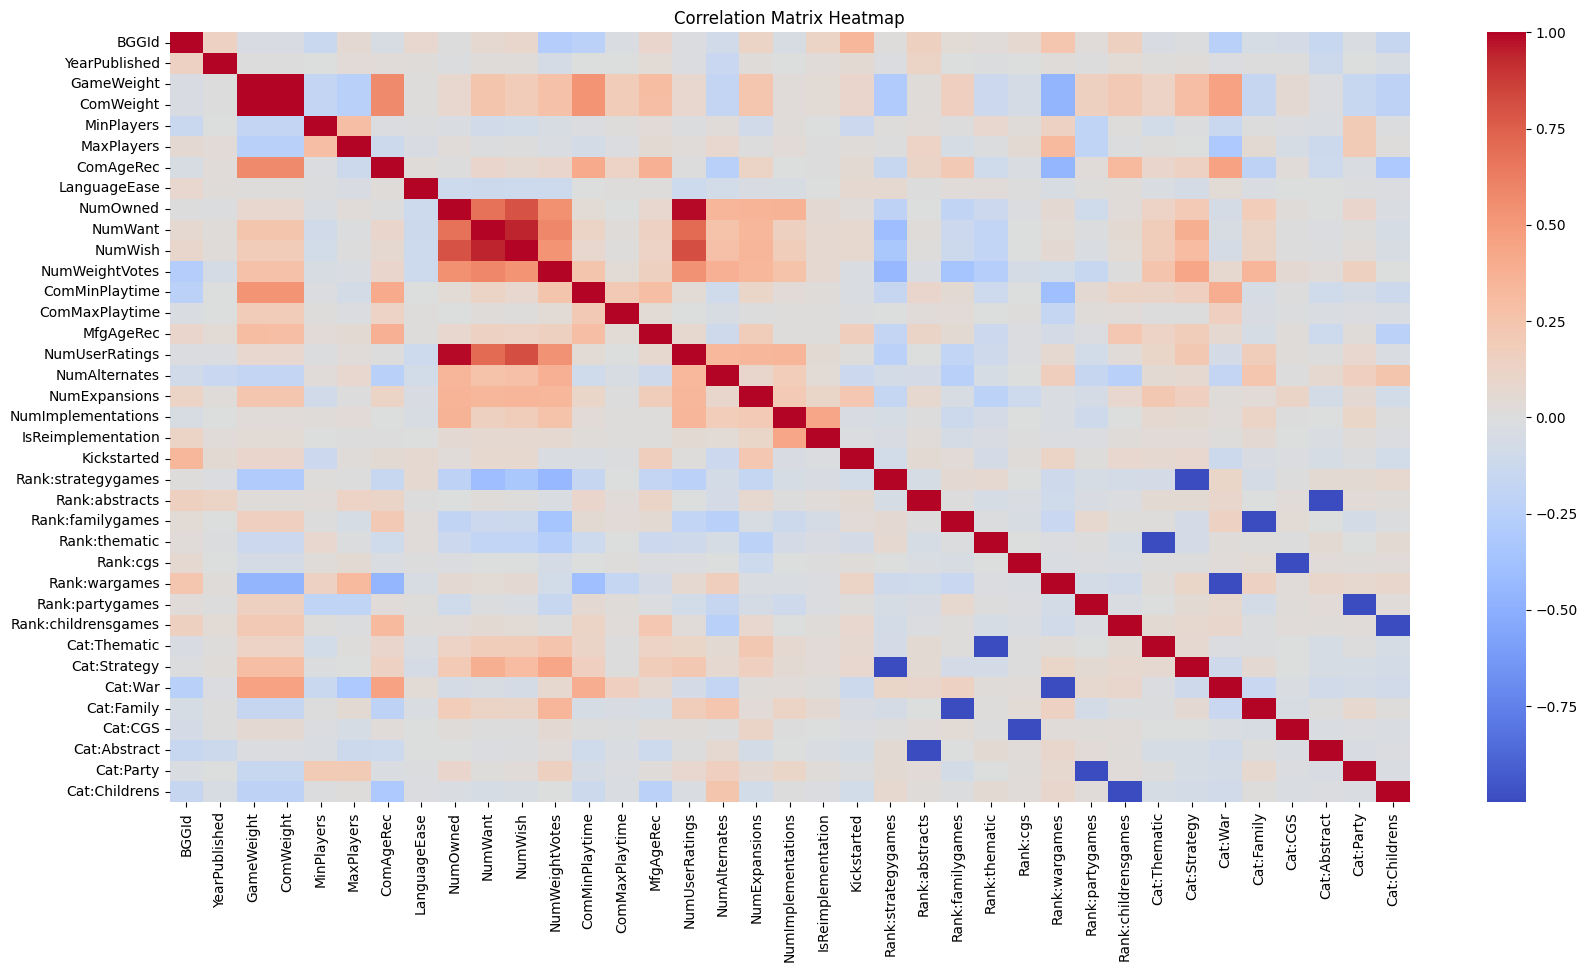

In [73]:
plt.figure(figsize=(20,10))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0, annot=False)
plt.title("Correlation Matrix Heatmap")
plt.show()


In [74]:
num_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = num_df.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr = [(row, col) for col in upper.columns for row in upper.index if upper.loc[row, col] > 0.90]

high_corr


[('GameWeight', 'ComWeight'),
 ('NumWant', 'NumWish'),
 ('NumOwned', 'NumUserRatings'),
 ('Rank:thematic', 'Cat:Thematic'),
 ('Rank:strategygames', 'Cat:Strategy'),
 ('Rank:wargames', 'Cat:War'),
 ('Rank:familygames', 'Cat:Family'),
 ('Rank:cgs', 'Cat:CGS'),
 ('Rank:abstracts', 'Cat:Abstract'),
 ('Rank:partygames', 'Cat:Party'),
 ('Rank:childrensgames', 'Cat:Childrens')]

Clean dataset Module_01

In [75]:
# Save the cleaned dataset to a new CSV file
df.to_csv("DM1_game_dataset_module.01.csv", index=False)


In [76]:
df.shape

(21925, 42)

In [77]:
df.dtypes

,0
BGGId,int64
Name,object
Description,object
YearPublished,int64
GameWeight,float64
ComWeight,float64
MinPlayers,int64
MaxPlayers,float64
ComAgeRec,float64
LanguageEase,float64


This is complete module 1.
Rank is going to be removed in clustering.
Data is cleaned.Any removal or procedure will be done according to our next module or after our talk with professor after mid submission.


In [78]:
df.shape

(21925, 42)

In [79]:
df.columns

Index(['BGGId', 'Name', 'Description', 'YearPublished', 'GameWeight',
       'ComWeight', 'MinPlayers', 'MaxPlayers', 'ComAgeRec', 'LanguageEase',
       'GoodPlayers', 'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes',
       'ComMinPlaytime', 'ComMaxPlaytime', 'MfgAgeRec', 'NumUserRatings',
       'NumAlternates', 'NumExpansions', 'NumImplementations',
       'IsReimplementation', 'Kickstarted', 'ImagePath', 'Rank:strategygames',
       'Rank:abstracts', 'Rank:familygames', 'Rank:thematic', 'Rank:cgs',
       'Rank:wargames', 'Rank:partygames', 'Rank:childrensgames',
       'Cat:Thematic', 'Cat:Strategy', 'Cat:War', 'Cat:Family', 'Cat:CGS',
       'Cat:Abstract', 'Cat:Party', 'Cat:Childrens', 'Rating'],
      dtype='object')